# When Does Spectral Similarity Become Dangerous?

This notebook investigates a practical Raman verification question:

**When do two spectra become dangerously similar for an automated identification system?**

The key issue is not whether clean spectra can be classified accurately, but whether highly similar spectra remain distinguishable under realistic measurement artefacts such as baseline drift, fluorescence-like background, noise, intensity scaling, and spectral shift.

The broader motivation is Raman-based compound verification systems, where the risk is not broad misclassification on clean data, but ambiguity between spectrally similar compounds under imperfect measurement conditions.

## Notebook logic

This notebook follows a simple progression:

1. Load and inspect the API Raman dataset  
2. Establish a clean baseline  
3. Simulate realistic measurement artefacts  
4. Compare raw and preprocessed pipelines  
5. Identify where failure concentrates  
6. Analyse hard compound pairs  
7. Connect the findings back to Raman verification systems

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import savgol_filter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 20)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Locate and load the dataset

The dataset contains 3,510 Raman spectra across 32 compounds, with one row per spectrum and one column per Raman shift. The final column contains the compound label.

In [2]:
PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"
RESULTS_REPORTS = PROJECT_ROOT / "results" / "reports"

data_file = DATA_RAW / "raman_spectra_api_compounds.csv"

print("Looking for file at:")
print(data_file)
print("Exists:", data_file.exists())

Looking for file at:
/Users/natashasmith/projects/spectral-drug-verification/data/raw/raman_spectra_api_compounds.csv
Exists: True


In [3]:
df = pd.read_csv(data_file)
print(df.shape)
df.head()

(3510, 3277)


,150.0,151.0,152.0,153.0,154.0,155.0,156.0,157.0,158.0,159.0,...,3417.0,3418.0,3419.0,3420.0,3421.0,3422.0,3423.0,3424.0,3425.0,label
0,2975.316162,2954.086182,2934.369385,2913.032959,2888.102783,2859.719482,2830.151855,2802.727051,2780.262451,2763.858643,...,805.636475,750.080505,501.523346,633.276245,1011.624146,938.956909,618.756042,536.374512,539.313660,"1,3-Dimethyl-2-imidazolidinone"
1,2562.031006,2530.818359,2504.126465,2482.523193,2463.468506,2443.604492,2421.537598,2398.885742,2378.914795,2364.093750,...,775.733398,473.567291,307.862976,694.032776,1100.932495,1034.330078,812.028442,643.311768,453.844269,"1,3-Dimethyl-2-imidazolidinone"
2,3706.918701,3675.912109,3649.161621,3625.712158,3603.918701,3582.241943,3560.217285,3538.892822,3520.142578,3505.149414,...,6174.322266,6202.327148,5898.275391,6000.154785,6350.005859,6264.735840,5855.383789,5519.607910,5564.967773,"1,3-Dimethyl-2-imidazolidinone"
3,2986.164795,2960.689209,2938.452881,2920.104492,2904.541260,2889.769775,2874.191162,2857.502441,2840.735352,2825.514893,...,5972.652832,5665.534668,5320.072754,5609.945312,6090.574219,6145.817871,5985.050781,5861.742676,5775.922852,"1,3-Dimethyl-2-imidazolidinone"
4,2739.325195,2721.701660,2702.028320,2679.959717,2655.924072,2631.208252,2607.982422,2588.531738,2573.780273,2562.305908,...,5171.950684,4560.865723,4135.452148,4482.227539,5077.244141,5226.481934,5074.020020,5089.577637,5415.591309,"1,3-Dimethyl-2-imidazolidinone"


In [4]:
X = df.drop(columns=["label"])
y = df["label"]

wavenumbers = X.columns.astype(float)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("Number of compounds:", y.nunique())

Feature matrix shape: (3510, 3276)
Labels shape: (3510,)
Number of compounds: 32


## 2. Visual inspection

Before doing anything clever, look at the signal. Raman classification only makes sense if we can see where the peaks sit and how much the baseline varies.

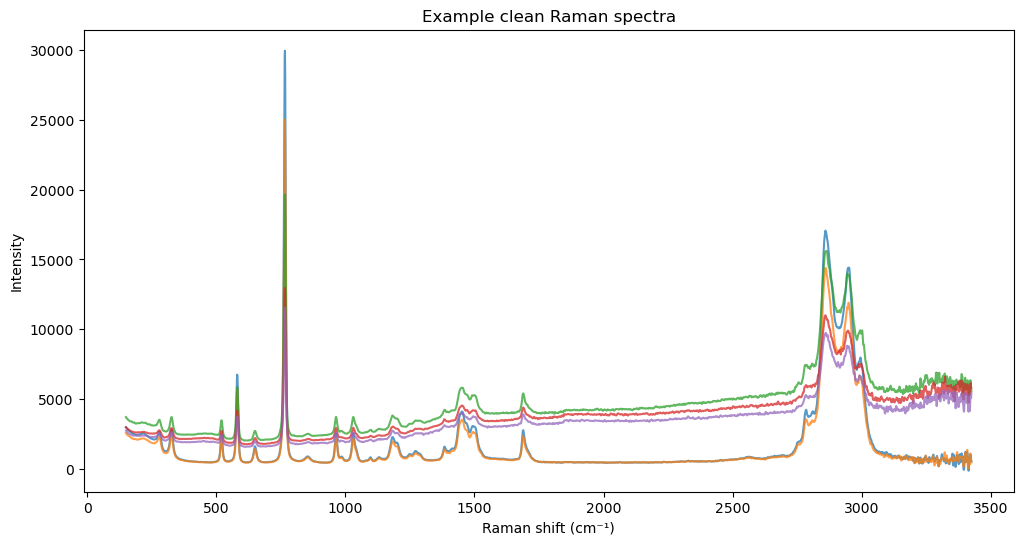

In [5]:
plt.figure(figsize=(12, 6))

for i in range(5):
    plt.plot(wavenumbers, X.iloc[i], alpha=0.75)

plt.xlabel("Raman shift (cm⁻¹)")
plt.ylabel("Intensity")
plt.title("Example clean Raman spectra")
plt.show()

In [6]:
y.value_counts().sort_index()

label
1,3-Dimethyl-2-imidazolidinone    109
2 - Propanol                      109
2, 2 - Dimethoxy Propane          107
4-Methyl-2-pentanone              100
Acetic acid                       113
                                 ... 
Tert-butyl methyl ether           117
Tetrahydrofuran                   100
Toluene                           127
n-Heptane                         103
n-Hexane                          102
Name: count, Length: 32, dtype: int64

## 3. Clean baseline classification

First establish how easy the task is under clean conditions. This gives a reference point before introducing any simulated distortion.

In [7]:
X_array = X.values
y_array = y.values

X_train, X_test, y_train, y_test = train_test_split(
    X_array,
    y_array,
    test_size=0.2,
    stratify=y_array,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape)

(2808, 3276) (702, 3276)


In [8]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50)),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
])

baseline_model.fit(X_train, y_train)
preds_clean = baseline_model.predict(X_test)

print("Clean accuracy:", accuracy_score(y_test, preds_clean))
print("Clean macro F1:", f1_score(y_test, preds_clean, average="macro"))

Clean accuracy: 0.9928774928774928
Clean macro F1: 0.9927651562009192


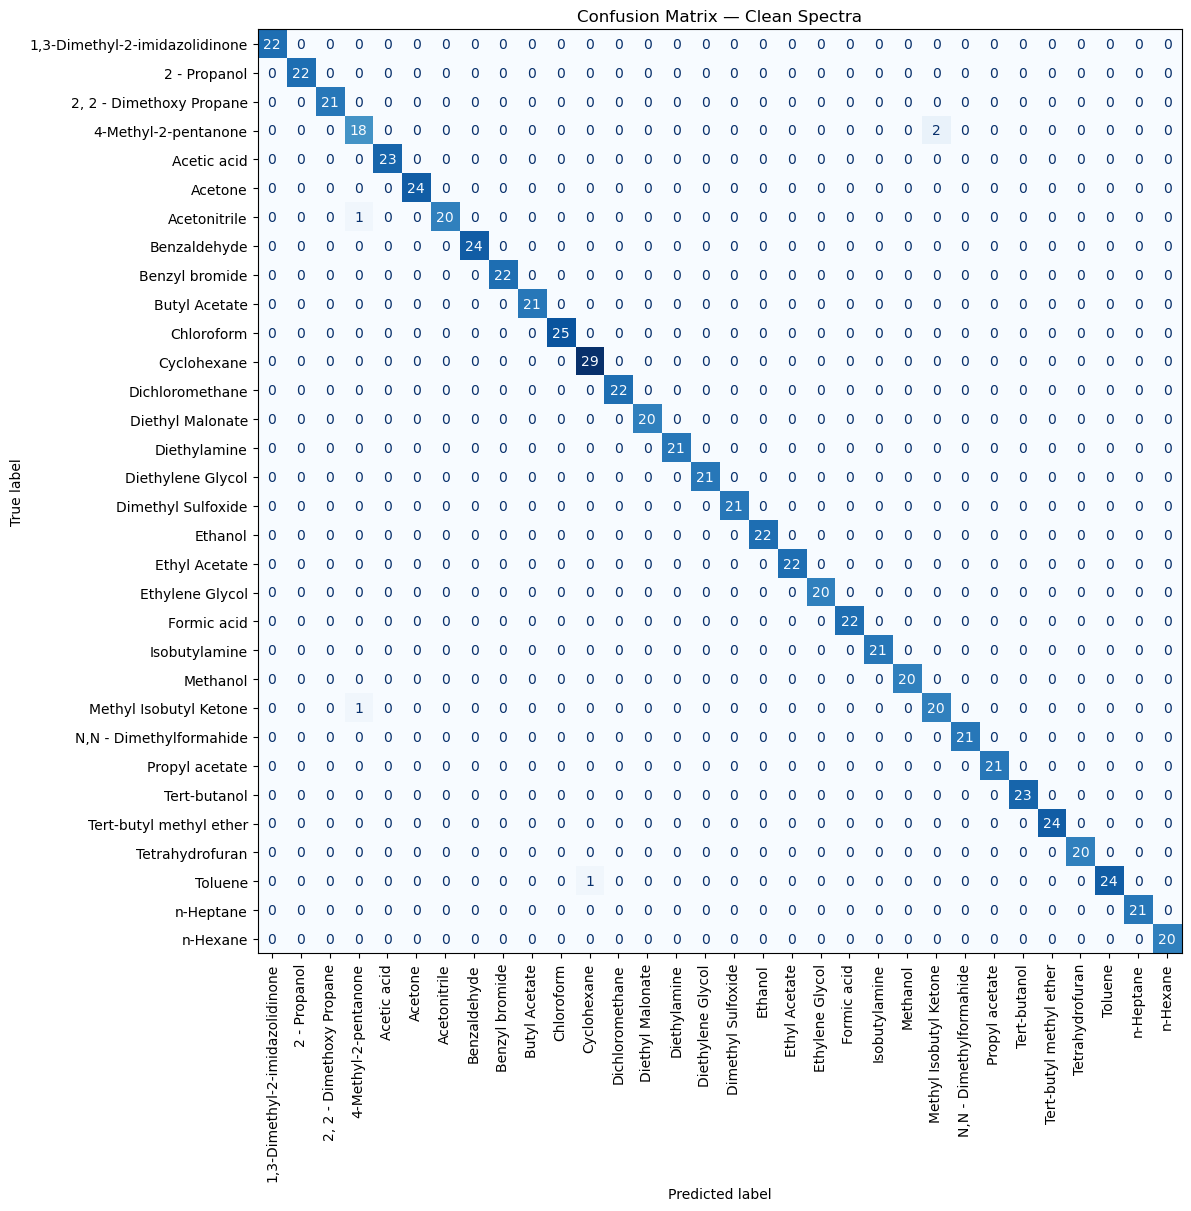

In [9]:
labels_sorted = sorted(np.unique(y_test))

cm_clean = confusion_matrix(y_test, preds_clean, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_clean, display_labels=labels_sorted)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix — Clean Spectra")
plt.show()

### Interpretation

If the clean task is already close to trivial, then the interesting question is no longer *can the model classify Raman spectra?* It becomes *what happens when the spectra are no longer ideal?*

## 4. Simulated measurement artefacts

Real Raman systems rarely produce completely destroyed spectra. More often, they produce spectra that still look plausible to a human, but are distorted enough to destabilise automated classification.

We simulate:

- Gaussian noise  
- baseline drift / fluorescence-like background  
- intensity scaling  
- wavenumber shift  
- combined distortions

In [10]:
def add_gaussian_noise(X, noise_std=0.02, random_state=42):
    rng = np.random.default_rng(random_state)
    scale = np.std(X, axis=1, keepdims=True)
    noise = rng.normal(0, noise_std, size=X.shape) * scale
    return X + noise

def add_baseline_drift(X, strength=0.15):
    n_samples, n_features = X.shape
    x_axis = np.linspace(0, 1, n_features)
    baseline = strength * (x_axis + 0.5 * x_axis**2)
    scale = np.max(X, axis=1, keepdims=True)
    return X + scale * baseline

def add_intensity_scaling(X, low=0.85, high=1.15, random_state=42):
    rng = np.random.default_rng(random_state)
    factors = rng.uniform(low, high, size=(X.shape[0], 1))
    return X * factors

def add_wavenumber_shift(X, max_shift=3, random_state=42):
    rng = np.random.default_rng(random_state)
    X_shifted = np.empty_like(X)
    for i in range(X.shape[0]):
        shift = rng.integers(-max_shift, max_shift + 1)
        X_shifted[i] = np.roll(X[i], shift)
    return X_shifted

def apply_combined_corruption(X, random_state=42):
    rng = np.random.default_rng(random_state)
    X_corr = []

    for row in X:
        r = row.copy()

        noise_std = rng.uniform(0.03, 0.08)
        r = r + rng.normal(0, noise_std * np.std(r), size=r.shape)

        x = np.linspace(0, 1, len(r))
        baseline_strength = rng.uniform(0.1, 0.4)
        baseline = baseline_strength * (x + 0.5 * x**2)
        r = r + baseline * np.max(r)

        scale = rng.uniform(0.7, 1.3)
        r = r * scale

        shift = rng.integers(-5, 6)
        r = np.roll(r, shift)

        X_corr.append(r)

    return np.array(X_corr)

In [11]:
X_test_noise = add_gaussian_noise(X_test, noise_std=0.03, random_state=RANDOM_STATE)
X_test_baseline = add_baseline_drift(X_test, strength=0.12)
X_test_scaled = add_intensity_scaling(X_test, low=0.9, high=1.1, random_state=RANDOM_STATE)
X_test_shifted = add_wavenumber_shift(X_test, max_shift=2, random_state=RANDOM_STATE)
X_test_combined = apply_combined_corruption(X_test, random_state=RANDOM_STATE)

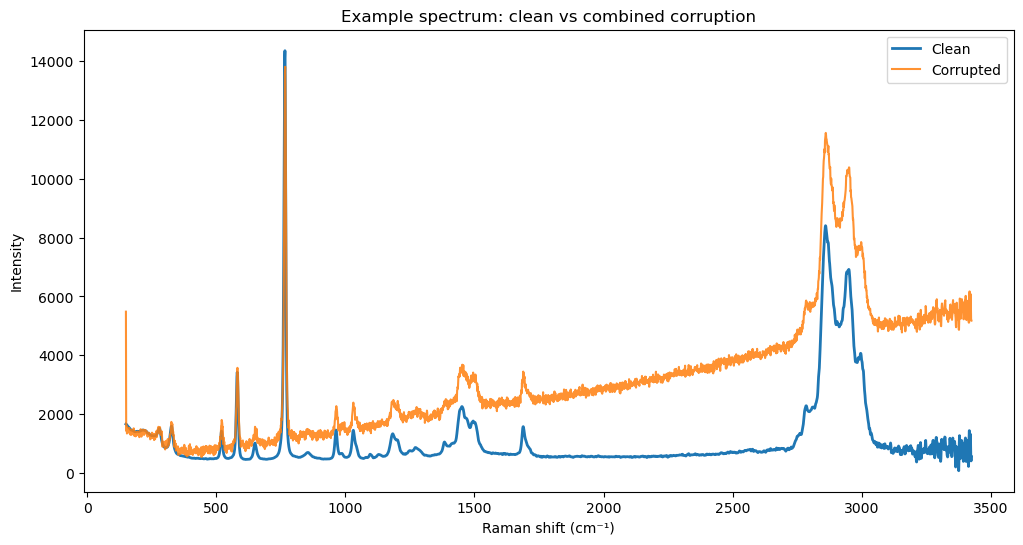

In [12]:
idx = 0

plt.figure(figsize=(12, 6))
plt.plot(wavenumbers, X_test[idx], label="Clean", linewidth=2)
plt.plot(wavenumbers, X_test_combined[idx], label="Corrupted", alpha=0.85)
plt.xlabel("Raman shift (cm⁻¹)")
plt.ylabel("Intensity")
plt.title("Example spectrum: clean vs combined corruption")
plt.legend()
plt.show()

## 5. Preprocessing pipeline

We compare raw spectra against a simple preprocessing chain:

1. Savitzky–Golay smoothing  
2. baseline correction  
3. per-spectrum normalisation  

The goal is to test whether preprocessing restores separability under distortion.

In [13]:
def smooth_spectra(X, window_length=11, polyorder=3):
    return np.array([
        savgol_filter(row, window_length=window_length, polyorder=polyorder)
        for row in X
    ])

def normalize_spectra(X):
    row_max = np.max(np.abs(X), axis=1, keepdims=True)
    row_max[row_max == 0] = 1
    return X / row_max

def simple_baseline_correction(X):
    corrected = []
    n_features = X.shape[1]
    x_idx = np.arange(n_features)

    for row in X:
        coeffs = np.polyfit(x_idx, row, deg=2)
        baseline = np.polyval(coeffs, x_idx)
        corrected.append(row - baseline)

    return np.array(corrected)

def preprocess_pipeline(X):
    X1 = smooth_spectra(X)
    X2 = simple_baseline_correction(X1)
    X3 = normalize_spectra(X2)
    return X3

## 6. Evaluate robustness

This is the key experiment:

- train on clean spectra  
- test on distorted spectra  

Then compare:

- raw pipeline  
- preprocessed pipeline  

We also compare two model classes to reduce the risk that the result is model-specific.

In [14]:
def evaluate_condition(X_train, y_train, X_test, y_test, use_preprocessing=False, model_type="rf"):
    Xtr = X_train.copy()
    Xte = X_test.copy()

    if use_preprocessing:
        Xtr = preprocess_pipeline(Xtr)
        Xte = preprocess_pipeline(Xte)

    if model_type == "rf":
        clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    elif model_type == "svm":
        clf = SVC(kernel="rbf", C=10, gamma="scale")
    else:
        raise ValueError("model_type must be 'rf' or 'svm'")

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=50)),
        ("clf", clf)
    ])

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    return {
        "accuracy": accuracy_score(y_test, preds),
        "macro_f1": f1_score(y_test, preds, average="macro"),
        "preds": preds,
        "model": model
    }

In [15]:
conditions = {
    "clean": X_test,
    "noise": X_test_noise,
    "baseline": X_test_baseline,
    "scaled": X_test_scaled,
    "shifted": X_test_shifted,
    "combined": X_test_combined,
}

results = {}

for model_type in ["rf", "svm"]:
    for condition_name, Xte in conditions.items():
        results[(model_type, condition_name, "raw")] = evaluate_condition(
            X_train, y_train, Xte, y_test,
            use_preprocessing=False,
            model_type=model_type
        )
        results[(model_type, condition_name, "preprocessed")] = evaluate_condition(
            X_train, y_train, Xte, y_test,
            use_preprocessing=True,
            model_type=model_type
        )

In [16]:
summary = []

for (model_type, condition, pipeline_mode), res in results.items():
    summary.append({
        "model": model_type,
        "condition": condition,
        "pipeline": pipeline_mode,
        "accuracy": res["accuracy"],
        "macro_f1": res["macro_f1"]
    })

summary_df = pd.DataFrame(summary).sort_values(["model", "condition", "pipeline"])
summary_df

,model,condition,pipeline,accuracy,macro_f1
5,rf,baseline,preprocessed,0.988604,0.988026
4,rf,baseline,raw,0.863248,0.822083
1,rf,clean,preprocessed,0.988604,0.988026
0,rf,clean,raw,0.994302,0.994296
11,rf,combined,preprocessed,0.975783,0.973427
...,...,...,...,...,...
14,svm,noise,raw,0.923077,0.930167
19,svm,scaled,preprocessed,0.972934,0.968202
18,svm,scaled,raw,0.921652,0.928317
21,svm,shifted,preprocessed,0.972934,0.968202


In [17]:
summary_pivot = summary_df.pivot_table(
    index=["condition", "pipeline"],
    columns="model",
    values="accuracy"
)
summary_pivot

model                         rf       svm
condition pipeline                        
baseline  preprocessed  0.988604  0.972934
          raw           0.863248  0.817664
clean     preprocessed  0.988604  0.972934
          raw           0.994302  0.924501
combined  preprocessed  0.975783  0.957265
          raw           0.648148  0.492877
noise     preprocessed  0.985755  0.972934
          raw           0.992877  0.923077
scaled    preprocessed  0.987179  0.972934
          raw           0.987179  0.921652
shifted   preprocessed  0.980057  0.972934
          raw           0.988604  0.923077

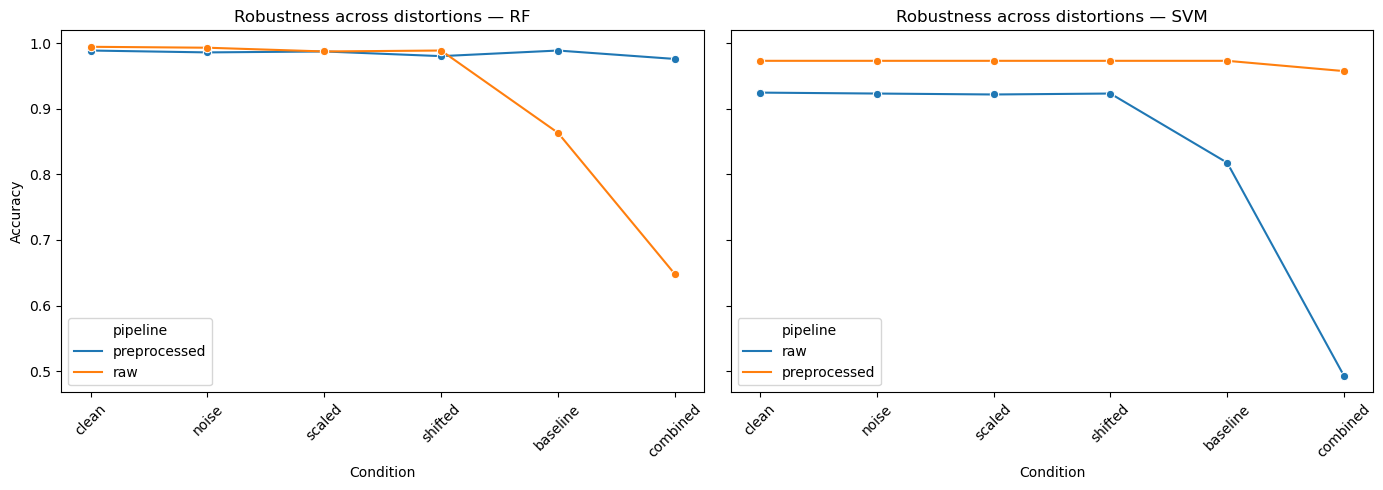

In [18]:
condition_order = ["clean", "noise", "scaled", "shifted", "baseline", "combined"]

plot_df = summary_df.copy()
plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=condition_order, ordered=True)
plot_df = plot_df.sort_values("condition")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, model_name in zip(axes, ["rf", "svm"]):
    sub = plot_df[plot_df["model"] == model_name]
    sns.lineplot(
        data=sub,
        x="condition",
        y="accuracy",
        hue="pipeline",
        marker="o",
        ax=ax
    )
    ax.set_title(f"Robustness across distortions — {model_name.upper()}")
    ax.set_xlabel("Condition")
    ax.set_ylabel("Accuracy")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

The most important comparison is not between classifiers but between **raw** and **preprocessed** spectra under distortion. If clean accuracy stays high but distorted accuracy collapses, then the real question becomes whether preprocessing restores the molecular information that the classifier depends on.

## 7. Where does failure concentrate?

Accuracy alone hides the interesting part. The key question is which compounds become confused under the hardest distortion condition, and whether preprocessing changes the nature of those failures.

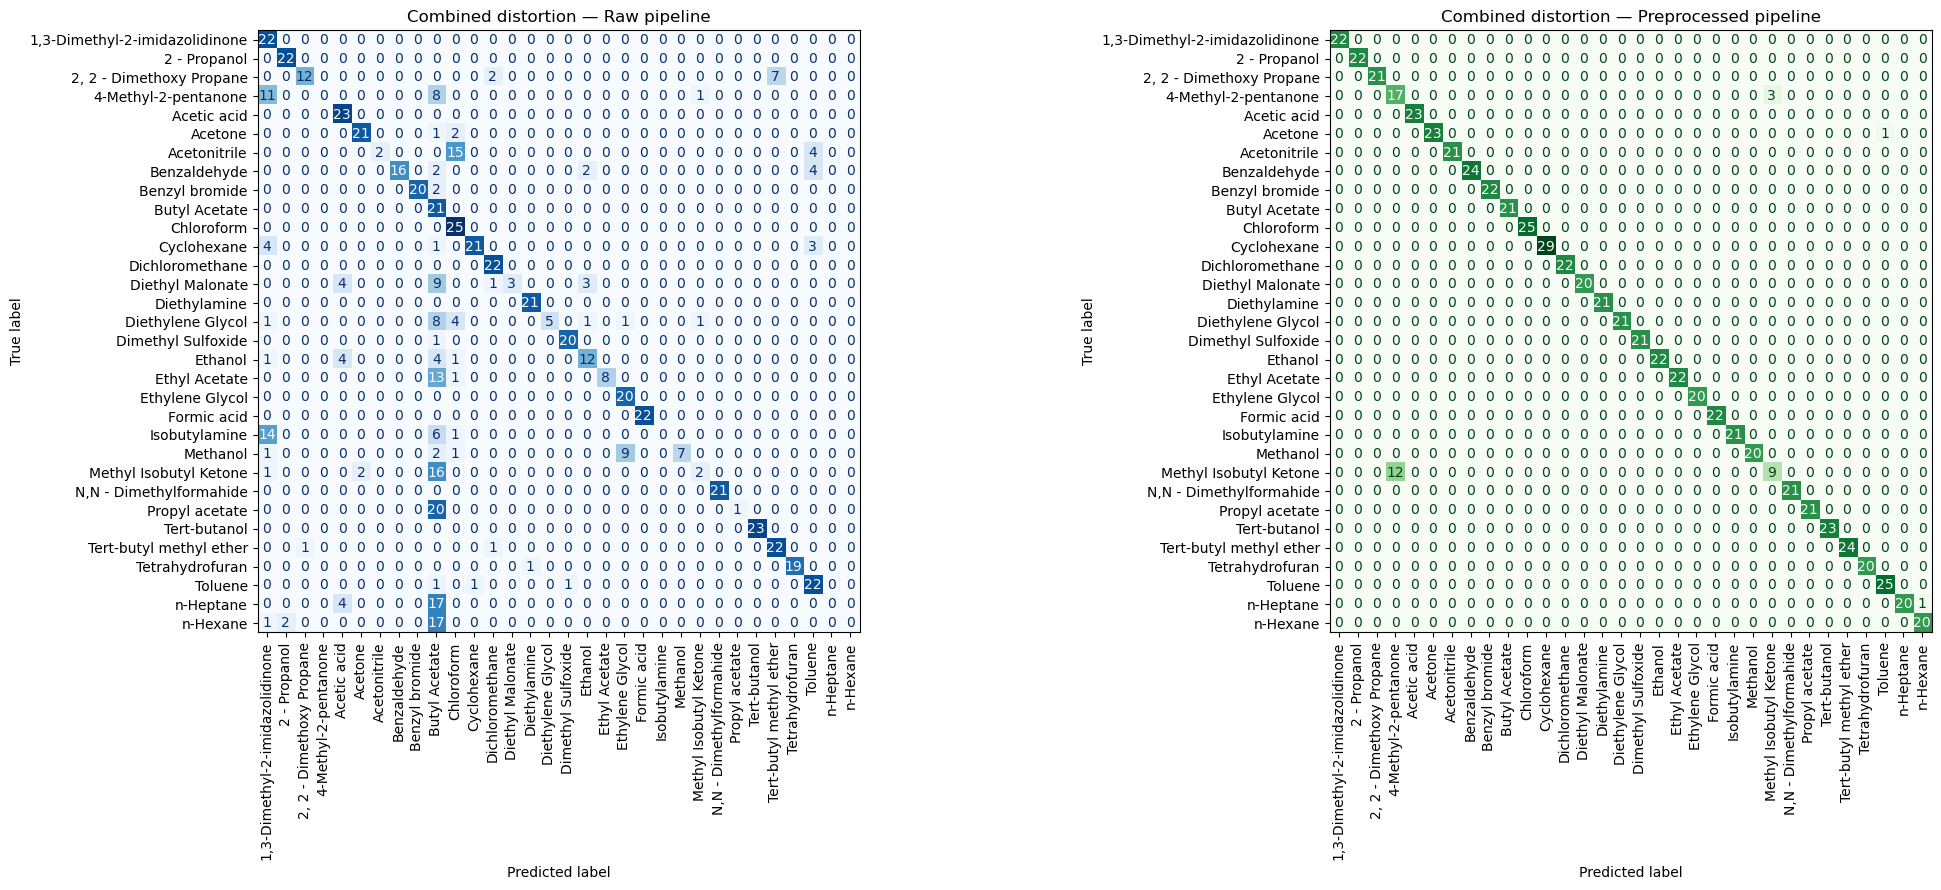

In [19]:
labels_sorted = sorted(np.unique(y_test))

cm_combined_raw = confusion_matrix(
    y_test,
    results[("rf", "combined", "raw")]["preds"],
    labels=labels_sorted
)

cm_combined_pre = confusion_matrix(
    y_test,
    results[("rf", "combined", "preprocessed")]["preds"],
    labels=labels_sorted
)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_combined_raw, display_labels=labels_sorted)
disp1.plot(ax=axes[0], cmap="Blues", xticks_rotation=90, colorbar=False)
axes[0].set_title("Combined distortion — Raw pipeline")

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_combined_pre, display_labels=labels_sorted)
disp2.plot(ax=axes[1], cmap="Greens", xticks_rotation=90, colorbar=False)
axes[1].set_title("Combined distortion — Preprocessed pipeline")

plt.tight_layout()
plt.show()

In [20]:
def get_top_confusions(cm, labels, top_n=15):
    rows = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:
                rows.append({
                    "true_label": labels[i],
                    "predicted_label": labels[j],
                    "count": cm[i, j]
                })
    df_conf = pd.DataFrame(rows)
    if df_conf.empty:
        return df_conf
    return df_conf.sort_values("count", ascending=False).head(top_n)

top_confusions_raw = get_top_confusions(cm_combined_raw, labels_sorted, top_n=20)
top_confusions_pre = get_top_confusions(cm_combined_pre, labels_sorted, top_n=20)

print("Top confusions — combined/raw")
display(top_confusions_raw)

print("\nTop confusions — combined/preprocessed")
display(top_confusions_pre)

Top confusions — combined/raw


,true_label,predicted_label,count
43,Propyl acetate,Butyl Acetate,20
54,n-Hexane,Butyl Acetate,17
51,n-Heptane,Butyl Acetate,17
42,Methyl Isobutyl Ketone,Butyl Acetate,16
7,Acetonitrile,Chloroform,15
33,Isobutylamine,"1,3-Dimethyl-2-imidazolidinone",14
31,Ethyl Acetate,Butyl Acetate,13
2,4-Methyl-2-pentanone,"1,3-Dimethyl-2-imidazolidinone",11
17,Diethyl Malonate,Butyl Acetate,9
39,Methanol,Ethylene Glycol,9



Top confusions — combined/preprocessed


,true_label,predicted_label,count
2,Methyl Isobutyl Ketone,4-Methyl-2-pentanone,12
0,4-Methyl-2-pentanone,Methyl Isobutyl Ketone,3
1,Acetone,Toluene,1
3,n-Heptane,n-Hexane,1


### Interpretation

A particularly important pattern is whether raw distorted spectra collapse toward a few dominant classes, while preprocessing restores chemically plausible confusions. That shift suggests the raw classifier is reacting to broad artefactual envelope structure, whereas the preprocessed classifier is once again using local diagnostic bands.

## 8. Hard-pair analysis

The broad multiclass problem is not the main challenge. The real problem lies in compounds that remain globally similar and differ only in small local spectral regions.

These are the true needle-in-a-haystack cases.

In [26]:
sorted(y.unique())

['1,3-Dimethyl-2-imidazolidinone',
 '2 - Propanol',
 '2, 2 - Dimethoxy Propane',
 '4-Methyl-2-pentanone',
 'Acetic acid',
 'Acetone',
 'Acetonitrile',
 'Benzaldehyde',
 'Benzyl bromide',
 'Butyl Acetate',
 'Chloroform',
 'Cyclohexane',
 'Dichloromethane',
 'Diethyl Malonate',
 'Diethylamine',
 'Diethylene Glycol',
 'Dimethyl Sulfoxide',
 'Ethanol',
 'Ethyl Acetate',
 'Ethylene Glycol',
 'Formic acid',
 'Isobutylamine',
 'Methanol',
 'Methyl Isobutyl Ketone',
 'N,N - Dimethylformahide',
 'Propyl acetate',
 'Tert-butanol',
 'Tert-butyl methyl ether',
 'Tetrahydrofuran',
 'Toluene',
 'n-Heptane',
 'n-Hexane']

In [30]:
hard_pairs = [
    ("Methanol", "Ethanol"),
    ("n-Hexane", "n-Heptane"),
    ("Ethyl Acetate", "Propyl acetate"),
    ("Ethyl Acetate", "Butyl Acetate"),
    ("Propyl acetate", "Butyl Acetate"),
    ("Methyl Isobutyl Ketone", "4-Methyl-2-pentanone"),
    ("Formic acid", "Tetrahydrofuran"),
]

In [31]:
def get_mean_spectrum(label, X_df, y_series):
    idx = np.where(y_series.values == label)[0]

    if len(idx) == 0:
        raise ValueError(f"Label not found in dataset: {label}")

    return X_df.iloc[idx].mean(axis=0).values


def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))



In [32]:
pair_rows = []

for a, b in hard_pairs:
    spec_a = get_mean_spectrum(a, X, y)
    spec_b = get_mean_spectrum(b, X, y)
    sim = cosine_similarity(spec_a, spec_b)

    pair_rows.append({
        "compound_a": a,
        "compound_b": b,
        "cosine_similarity": sim
    })

pair_df = pd.DataFrame(pair_rows).sort_values("cosine_similarity", ascending=False)
pair_df

,compound_a,compound_b,cosine_similarity
5,Methyl Isobutyl Ketone,4-Methyl-2-pentanone,0.999857
1,n-Hexane,n-Heptane,0.994470
4,Propyl acetate,Butyl Acetate,0.980919
2,Ethyl Acetate,Propyl acetate,0.965184
3,Ethyl Acetate,Butyl Acetate,0.935533
0,Methanol,Ethanol,0.823632
6,Formic acid,Tetrahydrofuran,0.604197


In [34]:
pair_rows = []

for a, b in hard_pairs:
    spec_a = get_mean_spectrum(a, X, y)
    spec_b = get_mean_spectrum(b, X, y)
    sim = cosine_similarity(spec_a, spec_b)

    pair_rows.append({
        "compound_a": a,
        "compound_b": b,
        "cosine_similarity": sim
    })

pair_df = pd.DataFrame(pair_rows).sort_values("cosine_similarity", ascending=False)
pair_df

,compound_a,compound_b,cosine_similarity
5,Methyl Isobutyl Ketone,4-Methyl-2-pentanone,0.999857
1,n-Hexane,n-Heptane,0.994470
4,Propyl acetate,Butyl Acetate,0.980919
2,Ethyl Acetate,Propyl acetate,0.965184
3,Ethyl Acetate,Butyl Acetate,0.935533
0,Methanol,Ethanol,0.823632
6,Formic acid,Tetrahydrofuran,0.604197


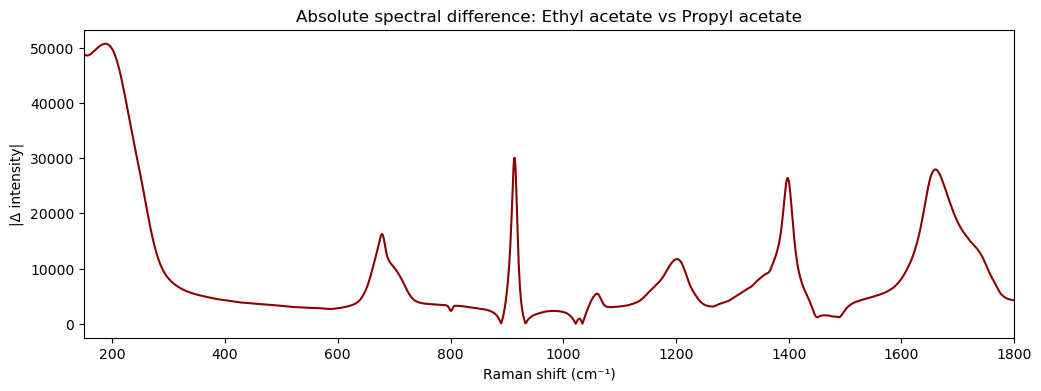

In [35]:
abs_diff = np.abs(spec_a - spec_b)

plt.figure(figsize=(12, 4))
plt.plot(wavenumbers, abs_diff, color="darkred")
plt.xlim(150, 1800)
plt.xlabel("Raman shift (cm⁻¹)")
plt.ylabel("|Δ intensity|")
plt.title(f"Absolute spectral difference: {compound_a} vs {compound_b}")
plt.show()

### Why this matters

Global similarity does not tell the full story. Two spectra can be highly similar overall and still be separable if the local differences sit on diagnostic peaks. Conversely, they can become effectively inseparable if those local differences are weak or degraded by measurement artefacts.

## 9. Fingerprint-region-only test

The Raman fingerprint region often carries the most compound-specific information. We test whether restricting the model to roughly 150–1800 cm⁻¹ materially changes performance.

In [36]:
fingerprint_mask = (wavenumbers >= 150) & (wavenumbers <= 1800)

X_fp = X.loc[:, fingerprint_mask]
X_fp_array = X_fp.values

X_train_fp, X_test_fp, y_train_fp, y_test_fp = train_test_split(
    X_fp_array,
    y_array,
    test_size=0.2,
    stratify=y_array,
    random_state=RANDOM_STATE
)

fp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50)),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
])

fp_model.fit(X_train_fp, y_train_fp)
fp_preds = fp_model.predict(X_test_fp)

print("Fingerprint-only accuracy:", accuracy_score(y_test_fp, fp_preds))
print("Fingerprint-only macro F1:", f1_score(y_test_fp, fp_preds, average="macro"))

Fingerprint-only accuracy: 0.9971509971509972
Fingerprint-only macro F1: 0.9969494047619047


## 10. What this means for Raman verification

Three conclusions matter most:

1. **Clean classification is easy; robust classification is hard.**  
2. **Baseline distortion is more dangerous than random noise.**  
3. **Global spectral similarity is not the same as safe separability.**

For a real Raman-based verification system, the main risk is not broad multiclass confusion on clean data. It is local ambiguity between highly similar compounds under imperfect measurement conditions.

That suggests:
- preprocessing is safety-critical, not cosmetic  
- local band-aware verification may matter more than marginal changes in model architecture  
- “similarity” should be interpreted chemically, not just geometrically

In [37]:
print("=== Key Takeaways ===")
print("1. Clean multiclass Raman classification is easy on this dataset.")
print("2. Combined distortions can sharply degrade raw classification.")
print("3. Preprocessing restores most lost separability.")
print("4. Remaining failures concentrate in chemically plausible hard pairs.")
print("5. Global spectral similarity alone is a poor indicator of danger.")
print("6. What matters is whether local diagnostic differences survive distortion.")

=== Key Takeaways ===
1. Clean multiclass Raman classification is easy on this dataset.
2. Combined distortions can sharply degrade raw classification.
3. Preprocessing restores most lost separability.
4. Remaining failures concentrate in chemically plausible hard pairs.
5. Global spectral similarity alone is a poor indicator of danger.
6. What matters is whether local diagnostic differences survive distortion.


In [38]:
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS_REPORTS.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(RESULTS_REPORTS / "robustness_summary.csv", index=False)
pair_df.to_csv(RESULTS_REPORTS / "hard_pair_similarities.csv", index=False)

print("Saved summary tables to results/reports/")

Saved summary tables to results/reports/


In [39]:
def get_mean_spectrum(label, X_df, y_series):
    idx = np.where(y_series.values == label)[0]
    if len(idx) == 0:
        raise ValueError(f"Label not found in dataset: {label}")
    return X_df.iloc[idx].mean(axis=0).values

In [40]:
def local_window_difference(spec_a, spec_b, wavenumbers, window_size=50):
    wn = np.array(wavenumbers)
    diffs = []

    start = wn.min()
    end = wn.max()

    current = start
    while current < end:
        mask = (wn >= current) & (wn < current + window_size)
        if mask.sum() > 0:
            diff = np.mean(np.abs(spec_a[mask] - spec_b[mask]))
            diffs.append({
                "window_start": current,
                "window_end": current + window_size,
                "window_mid": current + window_size / 2,
                "mean_abs_diff": diff
            })
        current += window_size

    return pd.DataFrame(diffs)

In [41]:
compound_a = "Ethyl Acetate"
compound_b = "Propyl acetate"

spec_a = get_mean_spectrum(compound_a, X, y)
spec_b = get_mean_spectrum(compound_b, X, y)

window_df = local_window_difference(spec_a, spec_b, wavenumbers, window_size=50)
window_df.sort_values("mean_abs_diff", ascending=False).head(10)

,window_start,window_end,window_mid,mean_abs_diff
55,2900.0,2950.0,2925.0,72511.404452
54,2850.0,2900.0,2875.0,37822.841209
56,2950.0,3000.0,2975.0,36562.373549
14,850.0,900.0,875.0,11828.238911
57,3000.0,3050.0,3025.0,10669.912078
26,1450.0,1500.0,1475.0,10093.943860
25,1400.0,1450.0,1425.0,8749.467193
3,300.0,350.0,325.0,8629.521121
16,950.0,1000.0,975.0,7154.479970
9,600.0,650.0,625.0,7031.371325


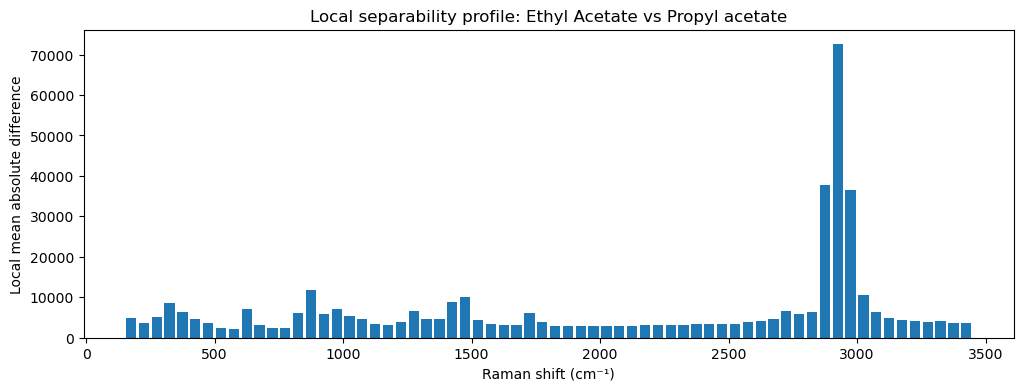

In [42]:
plt.figure(figsize=(12, 4))
plt.bar(window_df["window_mid"], window_df["mean_abs_diff"], width=40)
plt.xlabel("Raman shift (cm⁻¹)")
plt.ylabel("Local mean absolute difference")
plt.title(f"Local separability profile: {compound_a} vs {compound_b}")
plt.show()

In [43]:
def remove_region(X_df, wavenumbers, start, end):
    wn = np.array(wavenumbers)
    mask = (wn < start) | (wn > end)
    return X_df.loc[:, mask]

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [45]:
region_start = 2850
region_end = 3000

X_removed = remove_region(X, wavenumbers, region_start, region_end)

X_train, X_test, y_train, y_test = train_test_split(
    X_removed, y, test_size=0.2, stratify=y, random_state=42
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy without diagnostic region:", accuracy_score(y_test, y_pred))

Accuracy without diagnostic region: 0.9871794871794872


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def pairwise_accuracy(X_df, y_series, a, b):

    mask = (y_series == a) | (y_series == b)

    X_pair = X_df[mask]
    y_pair = y_series[mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X_pair, y_pair, test_size=0.2, stratify=y_pair, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)

    return accuracy_score(y_test, preds)

In [47]:
pair = ("Ethyl Acetate","Propyl acetate")

print("Full spectrum:", pairwise_accuracy(X, y, *pair))
print("Without CH region:", pairwise_accuracy(X_removed, y, *pair))

Full spectrum: 1.0
Without CH region: 1.0
